This is a demo of the capabilities of MPHvect to qualitatively map signed barcodes to vectors in ell_1. For this file, we focus on providing meaningful visuals to illustrate how this process encodes relevant features in 1-parameter persistence diagrams. Other uses for multiparameter persistence and persistence variants are provided in other example files. MPHvect is an implementation of the methods described in "A Schauder Basis for Multiparameter Persistence and Persitsence Variants": Peter Bubenik & Zachariah Ross, 2025.

In [1]:
!pip install git+https://github.com/ZachTRoss/MPHvect.git

#install other tools used for this example file
!pip install persim
#MPHvect works faster with numba installed
!pip install numba
!pip install nbformat

  Cloning https://github.com/ZachTRoss/MPHvect.git to /tmp/pip-req-build-juq2q028
  Running command git clone --filter=blob:none --quiet https://github.com/ZachTRoss/MPHvect.git /tmp/pip-req-build-juq2q028
  Resolved https://github.com/ZachTRoss/MPHvect.git to commit c88ebd74251b9b16967889e5cd6df1c6d08f6af3
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 42.7 MB/s eta 0:00:00
  Created wheel for MPHvect: filename=MPHvect-0.1.0-py3-none-any.whl size=10028 sha256=1bc686c238691007927b1e8961c25e8c01207e566f64f1525e39ae8d1a7e652b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ftjh4l8e/wheels/16/a7/37/f7d75b3a040fb4073e527243d839bd02415932158eb3594cb9
Successfully built MPHvect
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.9 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=6ba95fe3bd6e3e44c55af5d88285aabcaa3006cd066a2dc1

In [2]:
from MPHvect.method import*
from MPHvect.SVM_functions import *
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import gudhi as gd
from persim import plot_diagrams, PersLandscapeApprox
import sys
from sklearn.preprocessing import MinMaxScaler
import random
from plotly.subplots import make_subplots

Sample Data

In [3]:
#Here we define sampling methods for getting data sets which we will use in this example. Thanks to Himanshu Yadav for sharing script for these samplings.

def generate_eigenvalues_normal(std_dev=1, num=1000):
    mean = 0
    real_part = np.random.normal(mean, std_dev/np.sqrt(2*num), size=(num, num))
    imag_part = np.random.normal(mean, std_dev/np.sqrt(2*num), size=(num, num))

    complex_matrix = real_part + 1j * imag_part

    eigenvalues = np.linalg.eigvals(complex_matrix)

    pairs = [(np.real(val), np.imag(val)) for val in eigenvalues]

    random.shuffle(pairs)

    return np.array(pairs)*(1/1000)


def generate_unif_points_on_disc(num_points, not_scaled=True):
  list_x=[]
  list_y=[]
  for i in range(num_points):
    in_disk=False
    while in_disk==False:
      x = np.random.uniform(-1, 1)
      y = np.random.uniform(-1,1)
      if x**2 + y**2 <= 1:
        in_disk=True
        list_x.append(x)
        list_y.append(y)
  return np.array([list_x,list_y]).T



def sample_unit_disk_Gaussian(n, sigma=0.4):

  points_x=[]
  points_y=[]
  while len(points_x)<n:

    x = np.random.normal(loc=0.0, scale=sigma)
    y = np.random.normal(loc=0.0, scale=sigma)


    if np.linalg.norm([x,y])<=1:
      points_x.append(x)
      points_y.append(y)

  return np.array([points_x, points_y]).T



Below we illustrate examples of each of these sampling methods. First we define some plotting functions for convenience throughout this file.

In [4]:
#basic plotting functions
def plot_two_point_sets(array_1, array_2, point_size=6, ax_limit=None, titles= ["Point Set 1", "Points Set 2"]):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].scatter(array_1[:, 0], array_1[:, 1], s=point_size)
    axes[1].scatter(array_2[:, 0], array_2[:, 1], s=point_size)

    if ax_limit==None:


      all_x = np.concatenate([array_1[:, 0], array_2[:, 0]])
      all_y = np.concatenate([array_1[:, 1], array_2[:, 1]])

      x_min, x_max = all_x.min(), all_x.max()
      y_min, y_max = all_y.min(), all_y.max()

      axis_min=min(x_min, y_min)-0.1*(max(x_max,y_max)-min(x_min, y_min))
      axis_max=max(x_max, y_max)+0.1*(max(x_max,y_max)-min(x_min, y_min))

    if ax_limit is not None:
      axis_min=-0.1* ax_limit
      axis_max=1.1*ax_limit

    for ax, title in zip(axes, titles):
        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_title(title)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

def plot_three_point_sets(array_1, array_2, array_3, point_size=6, ax_limit=None, titles=["Point Set 1", "Point Set 2", "Point Set 3"]):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].scatter(array_1[:, 0], array_1[:, 1], s=point_size)
    axes[1].scatter(array_2[:, 0], array_2[:, 1], s=point_size)
    axes[2].scatter(array_3[:, 0], array_3[:, 1], s=point_size)

    if ax_limit is None:
        all_x = np.concatenate([array_1[:, 0], array_2[:, 0], array_3[:, 0]])
        all_y = np.concatenate([array_1[:, 1], array_2[:, 1], array_3[:, 1]])

        x_min, x_max = all_x.min(), all_x.max()
        y_min, y_max = all_y.min(), all_y.max()

        axis_min = min(x_min, y_min) - 0.1 * (max(x_max, y_max) - min(x_min, y_min))
        axis_max = max(x_max, y_max) + 0.1 * (max(x_max, y_max) - min(x_min, y_min))

    else:
        axis_min = -0.1 * ax_limit
        axis_max = 1.1 * ax_limit

    for ax, title in zip(axes, titles):
        ax.set_xlim(axis_min, axis_max)
        ax.set_ylim(axis_min, axis_max)
        ax.set_title(title)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()





def plot_two_point_sets_3d(array_1, array_2, point_size=2):


    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=("Point Set 1", "Point Set 2")
    )


    fig.add_trace(
        go.Scatter3d(
            x=array_1[:, 0],
            y=array_1[:, 1],
            z=array_1[:, 2],
            mode='markers',
            marker=dict(size=point_size, opacity=0.7)
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter3d(
            x=array_2[:, 0],
            y=array_2[:, 1],
            z=array_2[:, 2],
            mode='markers',
            marker=dict(size=point_size, opacity=0.7)
        ),
        row=1, col=2
    )
    all_points = np.vstack([array_1, array_2])
    x_min, y_min, z_min = all_points.min(axis=0)
    x_max, y_max, z_max = all_points.max(axis=0)


    scene_settings = dict(
        xaxis=dict(range=[-1.25,1.25], title='X'),
        yaxis=dict(range=[-1.25,1.25], title='Y'),
        zaxis=dict(range=[-1.25,1.25], title='Z'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1)
    )

    fig.update_layout(
        scene=scene_settings,
        scene2=scene_settings,
        title="Comparison of Two 3D Point Sets"
    )

    fig.show()


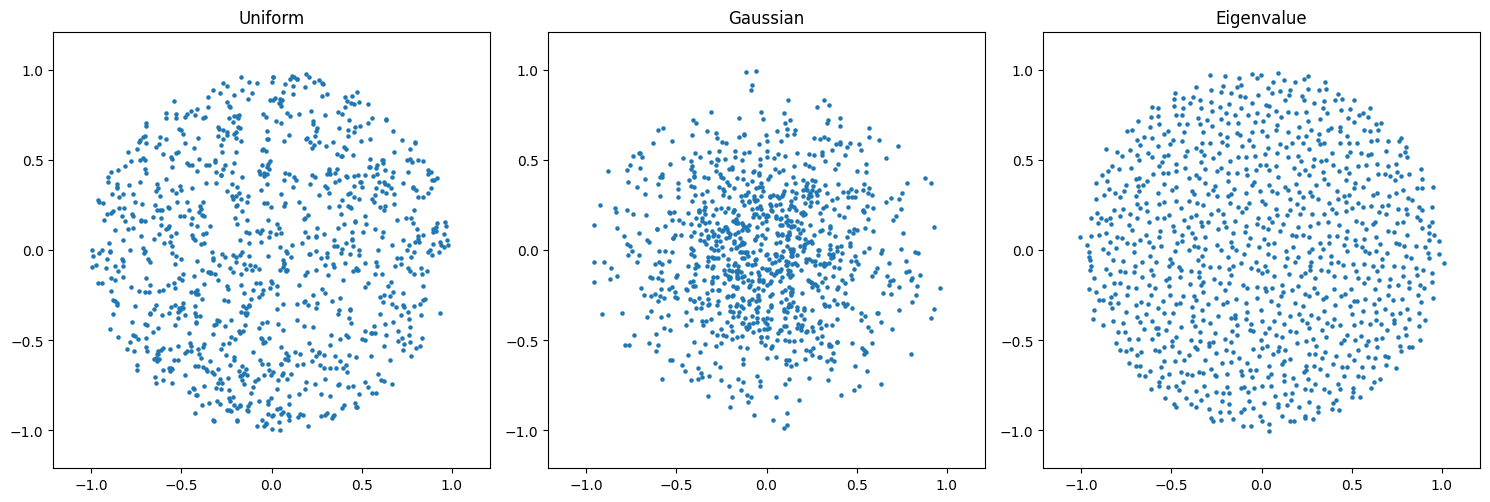

In [5]:
#Uniform Sampling
points_1=generate_unif_points_on_disc(1000)

#Gaussian Sampling
points_2=sample_unit_disk_Gaussian(1000)

#Eigenvalue Sampling
points_3=generate_eigenvalues_normal(1000)

plot_three_point_sets(points_1, points_2, points_3, point_size=5, titles= ["Uniform", "Gaussian", "Eigenvalue"])


Now let's compare the persistence diagrams of each sampling

In [6]:
#Computes the persistence diagram for homology in degree 1
def compute_PD(points):
  alpha = gd.AlphaComplex(points=points)
  st = alpha.create_simplex_tree()
  st.persistence()
  H1 = st.persistence_intervals_in_dimension(1)

  return H1

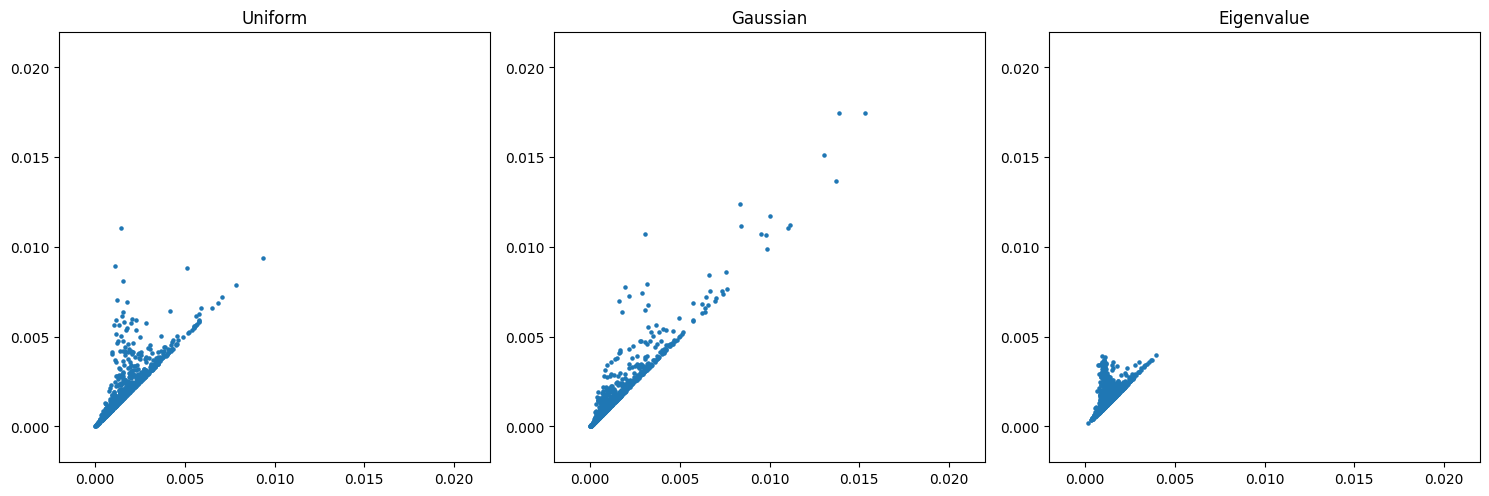

In [7]:
PD_1=compute_PD(points_1)
PD_2=compute_PD(points_2)
PD_3=compute_PD(points_3)

plot_three_point_sets(PD_1, PD_2, PD_3, point_size=5, ax_limit=0.02, titles= ["Uniform", "Gaussian", "Eigenvalue"])

Experiment 1: Uniform VS Gaussian Disk Sampling

In this first experiment, we sample 1000 iterations of both uniform and Gaussian sampling.

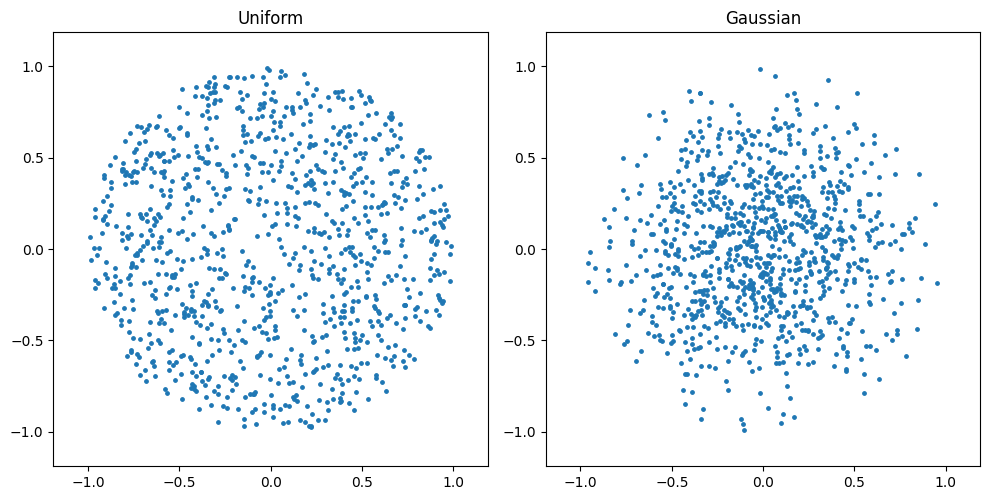

In [8]:
Sample_Uniform=generate_unif_points_on_disc(1000)
Sample_Gaussian=sample_unit_disk_Gaussian(1000)

plot_two_point_sets(Sample_Uniform, Sample_Gaussian, titles=["Uniform", "Gaussian"])


In [21]:
#Now we sample data points 'iteration' times for each sampling method, and calculate each persistence diagram
iterations=1000
num_points=1000

Points_Unif=[]
Points_Gaus=[]
PDs_Unif_raw=[]
PDs_Gaus_raw=[]
for i in range(iterations):
  Points_Unif.append(generate_unif_points_on_disc(num_points))
  Points_Gaus.append(sample_unit_disk_Gaussian(num_points))

  PDs_Unif_raw.append(compute_PD(Points_Unif[i]))
  PDs_Gaus_raw.append(compute_PD(Points_Gaus[i]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [22]:
#Normalizations

#First, these data sets can have significant differences in total persistence dependent on which sampling method is used.
#MPHvect maps persistence diagrams to a vector in ell_1, for which the first coordinate is a constant multiple of total persistence.
#So to make things harder, we will first normalize each persistence diagram to have total persistence =1

def normalize_by_tot_pers(list_of_pds):
  new_list=[]
  for pd in list_of_pds:
    total=0
    for x,y in pd:
      total+=y-x
    for i in range(len(pd)):
      pd[i]=[pd[i][0]/total, pd[i][1]/total]
    new_list.append(pd)
  return new_list

def normalize_pd_by_tote(pd):
  new_pd=[None for _ in range(len(pd))]
  total=0
  for x,y in pd:
    total+=y-x
  scale=50
  for i in range(len(pd)):
    new_pd[i]=[ scale*pd[i][0]/total, scale*pd[i][1]/total]
  return new_pd


#Our method works by evaluating a Schauder basis of functionals on the upper left half of the plane.
#While this method works for our persistence diagrams as they are, it works more efficiently if we normalize all the persistence diagrams to "fill out" the unit square.
#This avoids having large numbers of functionals in the Schauder basis evaluating to 0: i.e. having long vectors for which most entries are 0.



def get_norm_val(pd):
  new_pd=pd[np.argsort(-pd[:,1]+pd[:,0])]


  cutoff=5
  new_new_pd=new_pd[:int(cutoff)]
  norm_val= np.max(new_new_pd[:,1])


  return 1.1*norm_val

def get_overall_norm_val(PDs):
  union=np.vstack(PDs)
  return get_norm_val(union)

def normalize_pd(pd, norm_val=None):
  if norm_val is None:
    norm_val=get_norm_val(pd)
  new_pd=(norm_val**(-1))*0.9*pd
  return new_pd

In [23]:
#Normalize the persistence diagrams according to defined norm_vals. These are the values we chose to represent the "relevant upper bound" of points of each class of the persistence diagrams.
#Note that these values are not necessarily the maximum death value of all poitns of the diagrams in each class.
#Rather, these values are the maximum death values of some of the most persistent points.

PDs_Unif=normalize_by_tot_pers(PDs_Unif_raw)
PDs_Gaus=normalize_by_tot_pers(PDs_Gaus_raw)

norm_val=max(get_overall_norm_val(PDs_Gaus), get_overall_norm_val(PDs_Unif))
print(norm_val)


PDs_Gaus=[(1/norm_val)*x for x in PDs_Gaus]
PDs_Unif=[(1/norm_val)*x for x in PDs_Unif]




0.09957704201161967


0.05009980376066437
0.1338188059825025


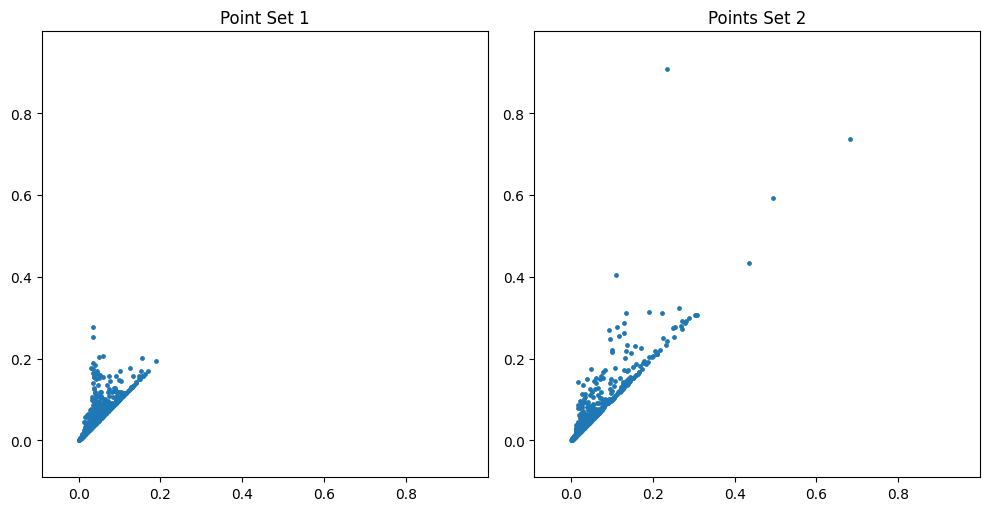

In [24]:
#Let's plot the two persistence diagrams at the index that obtained the norm_val above
vals_U=[get_norm_val(PDs_Unif_raw[i]) for i in range(len(PDs_Unif))]
vals_G=[get_norm_val(PDs_Gaus_raw[i]) for i in range(len(PDs_Gaus))]


print(np.max(vals_U))
print(np.max(vals_G))
index = vals_G.index(norm_val)


sample_pd_Uniform=PDs_Unif[index]
sample_pd_Gaussian=PDs_Gaus[index]

plot_two_point_sets(sample_pd_Uniform, sample_pd_Gaussian)

In [25]:
#We now map each persistence diagram to a vector in R^n, using the Schauder Basis method. For visualization purposes, we will choose a larger than necessary number of triangulation refinements.
#This will take longer to compute but will yield smooth visuals
#The inputs: dim is the number of parameters for which we are using persistence homology (i.e. 1-parameter persistence): max layer is the maximal number of refinements we take of the Coxeter Freudenthal Kuhn triangulation
#we take in order to define our subset of the associated Schauder Basis. min_layer is the first refinement we consider in our construction of such a subset of funcitonals.

n_list, p_list=collect_vertices(dim=1,max_layer=7,min_layer=4)

Vectors_Unif=[]
Vectors_Gaus=[]
for i in range(iterations):
  Vectors_Unif.append(vectorize_fast(n_list, p_list, np.array(PDs_Unif[i]), [1 for _ in range(len(PDs_Unif[i]))]))
  Vectors_Gaus.append(vectorize_fast(n_list, p_list, np.array(PDs_Gaus[i]), [1 for _ in range(len(PDs_Gaus[i]))]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [26]:
#We may visualize a single one of these vectors using the nailbed technique. In the below example, a single persistence diagram from each sampling method is fixed. Instead of mapping each persistence diagram to a vector,
#we treat each point of each diagram as its own persistence diagram. We then map each point to a vector in R^n using the method of MPHvect, and visualize this vectors as a color coded line segement below.
#The lengths of each colored section of the line segment correspond to coordinates of the resulting vector from MPHvect for that point of the diagram.
#We do this for each point of the diagram. The sum of these individual vectors is
#the final vectorization of the entire persistence diagram


MPHvect_nailbed(sample_pd_Uniform, number_of_triangulations=5)
MPHvect_nailbed(sample_pd_Gaussian, number_of_triangulations=5)

Output hidden; open in https://colab.research.google.com to view.

In [27]:
#while the nailbed visualization is useful for seeing how the magnitude of a vector is obtained through the the collection of points of a diagram,
#this visualization does not lend itself eaily for visualizing averages of the vectors obtained from the Schauder basis method.
#For this purpose, we introduce another visualization here.
#We take as input a given vector v, and parameters necessary for defining a finite subset B of a Schauder basis of functionals used to create v.
#Each coordinate in v corresponds to a unique functional in B.
#The output of this is a single function on the upper-left half of the plane, equal to the scaled sum (v[i]* B[i]).




In [28]:
#We can plot such a visual for each of the example persistence diagrams for each of the sampling methods.
#Since we have saved the normalization value from earlier, we will undo this normalization now for the visualization.
#Thus the result is a visual for the vectorization of the persistence diagrams at index=index, normalized only with respect to total persistence.

vis_vector(Vectors_Unif[index], n_list, p_list, norm_val=norm_val, title='Vector: Uniform Sampling')
vis_vector(Vectors_Gaus[index], n_list, p_list, norm_val=norm_val, title='Vector: Gaussian Sampling')

In [29]:
#We now take the average of the resulting vectors of all 1000 samplings of each method, and visualize these average vectors.
Unif_mean=np.mean(Vectors_Unif,axis=0)
Gaus_mean=np.mean(Vectors_Gaus,axis=0)

print("Mean of Unif Vectors:" , Unif_mean)
print("Mean of Gaus Vectors:" , Gaus_mean)

Mean of Unif Vectors: [51.61213269  6.43715705  1.69275572 ...  0.          0.
  0.        ]
Mean of Gaus Vectors: [5.35292798e+01 3.02279445e+00 2.88304949e-01 ... 0.00000000e+00
 5.49770201e-04 1.21285527e-03]


In [30]:
vis_vector(Unif_mean, n_list, p_list, norm_val=norm_val, title='Average Vector of Uniform Samplings')
vis_vector(Gaus_mean, n_list, p_list, norm_val=norm_val, title='Average Vector of Gaussian Samplings')



In [31]:
#we may visualize the difference of the two mean vectors below
vis_vector(Gaus_mean-Unif_mean, n_list, p_list, title='Difference of Average Uniform and Average Gaussian Vectors')

Observed accuracy: 1.0000
Permutation p-value: 0.0000


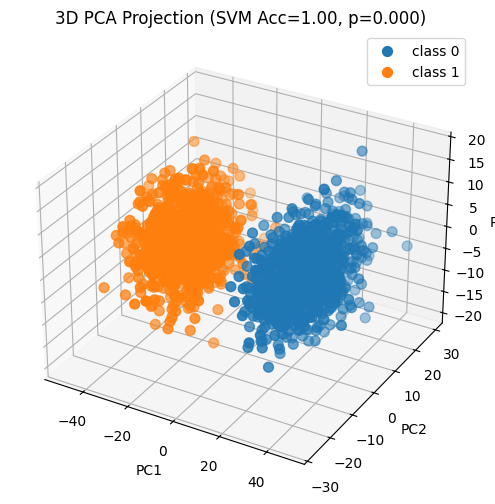

Standard Deviation of Unif Vectors 1.6801457174086127
Standard Deviation of Gaus Vectors 1.4788285134896049


In [32]:
#We now attempt to classify these vectors using Support Vector Machine (SVM).
#We also do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.
do_SVM_and_PCA(Vectors_Unif, Vectors_Gaus)
print("Standard Deviation of Unif Vectors", np.std(Vectors_Unif))
print("Standard Deviation of Gaus Vectors", np.std(Vectors_Gaus))

Experiment 2: Uniform VS Eigenvalue Sampling

Here we perform the same process in experiment 1, comparing uniform sampling and sampling using complex Eigenvalues

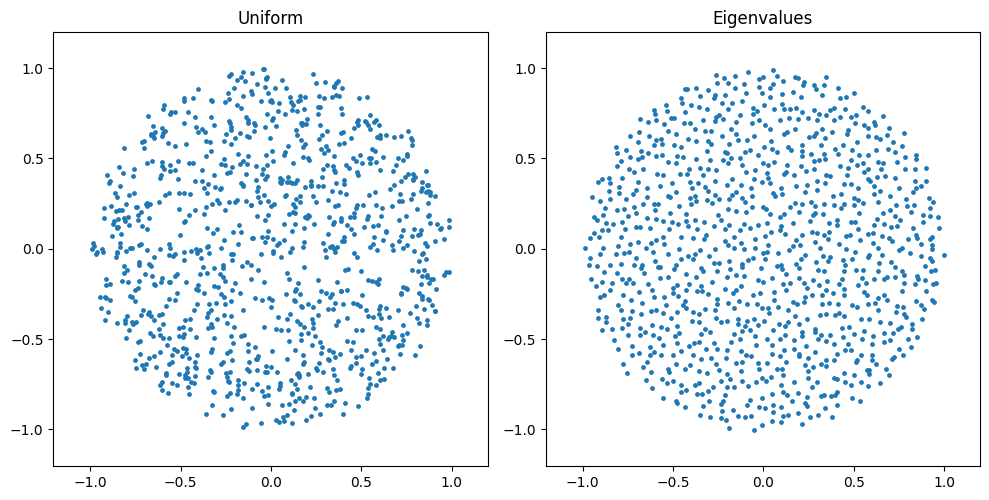

In [33]:
Sample_Uniform=generate_unif_points_on_disc(1000)
Sample_Eigen=generate_eigenvalues_normal(1000)

plot_two_point_sets(Sample_Uniform, Sample_Eigen, titles=["Uniform", "Eigenvalues"])


In [34]:
iterations=1000
num_points=1000

Points_Unif_2=[]
Points_Eigen=[]
PDs_Unif_2_raw=[]
PDs_Eigen_raw=[]

for i in range(iterations):
  Points_Unif_2.append(generate_unif_points_on_disc(num_points))
  Points_Eigen.append(generate_eigenvalues_normal(1,num_points))

  PDs_Unif_2_raw.append(compute_PD(Points_Unif[i]))
  PDs_Eigen_raw.append(compute_PD(Points_Eigen[i]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [35]:
#Normalize by total persistence, then by "relevant maximum death value"

PDs_Unif_2=normalize_by_tot_pers(PDs_Unif_2_raw)
PDs_Eigen_raw=normalize_by_tot_pers(PDs_Eigen_raw)


norm_val=max(get_overall_norm_val(PDs_Unif_2_raw), get_overall_norm_val(PDs_Eigen_raw))
print("norm val = ",norm_val)




PDs_Eigen=[(1/norm_val)*x for x in PDs_Eigen_raw]
PDs_Unif_2=[(1/norm_val)*x for x in PDs_Unif_raw]




norm val =  0.047885102216177894


0.05009980376066437
0.016664656759129162


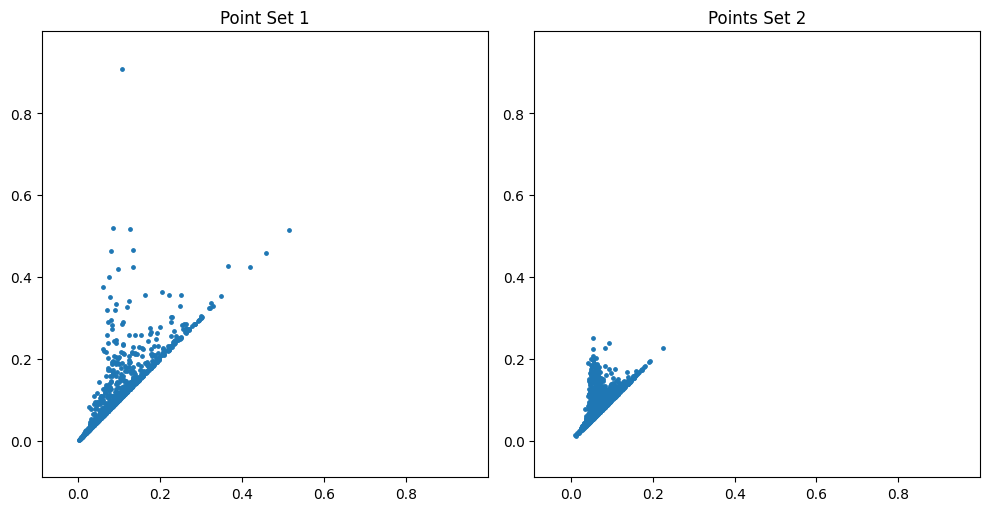

In [36]:
#Plot persistence diagrams at index achieving max normalization value
vals_U=[get_norm_val(PDs_Unif_2_raw[i]) for i in range(iterations)]
vals_E=[get_norm_val(PDs_Eigen_raw[i]) for i in range(iterations)]


print(np.max(vals_U))
print(np.max(vals_E))

if norm_val in vals_U:
  index = vals_U.index(norm_val)
if norm_val in vals_E:
  index = vals_E.index(norm_val)


sample_pd_Uniform=PDs_Unif_2[index]
sample_pd_Eigen=PDs_Eigen[index]

plot_two_point_sets(sample_pd_Uniform, sample_pd_Eigen)

In [37]:
#Map each persistence diagram to a vector using MPHvect
n_list, p_list=collect_vertices(1,7,4)

Vectors_unif_2=[]
Vectors_Eigen=[]
for i in range(iterations):
  Vectors_unif_2.append(vectorize_fast(n_list, p_list, np.array(PDs_Unif_2[i]), [1 for _ in range(len(PDs_Unif_2[i]))]))
  Vectors_Eigen.append(vectorize_fast(n_list, p_list, np.array(PDs_Eigen[i]), [1 for _ in range(len(PDs_Eigen[i]))]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [38]:
#We may visualize a single one of these vectors using the nailbed technique. In the below example, a single persistence diagram from each sampling method is fixed. Instead of mapping each persistence diagram to a vector,
#we treat each point of each diagram as its own persistence diagram. We then map each point to a vector in R^n using the method of MPHvect, and visualize this vectors as a color coded line segement below.
#The lengths of each colored section of the line segment correspond to coordinates of the resulting vector from MPHvect for that point of the diagram.
#We do this for each point of the diagram. The sum of these individual vectors is the final vectorization of the entire persistence diagram

MPHvect_nailbed(sample_pd_Uniform, number_of_triangulations=5)
MPHvect_nailbed(sample_pd_Eigen, number_of_triangulations=5)

Output hidden; open in https://colab.research.google.com to view.

In [39]:
#Determine the average resulting vector of each class
Unif_mean_2=np.mean(Vectors_unif_2,axis=0)
Eigen_mean=np.mean(Vectors_Eigen,axis=0)

print("Mean of Unif Vectors", Unif_mean_2)
print("Mean Deviation of Eigen Vectors", Eigen_mean)

Mean of Unif Vectors [17.47885842  0.69874046  0.16256096 ...  0.          0.
  0.        ]
Mean Deviation of Eigen Vectors [30.9520188   7.26294551  1.68518207 ...  0.          0.
  0.        ]


In [40]:
vis_vector(Unif_mean_2, n_list, p_list, norm_val=norm_val, title='Average Vector: Uniform Sampling')
vis_vector(Eigen_mean, n_list, p_list, norm_val=norm_val, title='Average Vector: Sampling with Eigenvalues')
vis_vector(Unif_mean_2-Eigen_mean, n_list, p_list, norm_val=norm_val, title='Difference of Average Vectors')

Observed accuracy: 1.0000
Permutation p-value: 0.0000


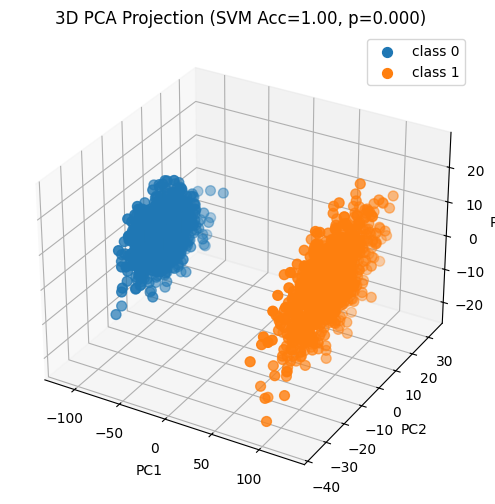

Standard Deviation of Unif Vectors 1.539803970129193
Standard Deviation of Eigen Vectors 3.184388040366125


In [41]:
#We now attempt to classify these vectors using Support Vector Machine (SVM).
#We also do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.
do_SVM_and_PCA(Vectors_unif_2, Vectors_Eigen)
print("Standard Deviation of Unif Vectors", np.std(Vectors_unif_2))
print("Standard Deviation of Eigen Vectors", np.std(Vectors_Eigen))

Experiment 3: Sphere VS Torus Sampling

In [42]:
#In this experiment, we compare two types of sampling points in three dimensions. For one class of data, we sample uniformly from the sphere.
#For the second class of data, we sample uniformly from the torus using the method described in "Sampling from a Manifold " by Persi Diaconis, Susan Holmes, Mehrdad Shahshahani: https://arxiv.org/abs/1206.6913

def sample_theta(n, R, r):
    """
    Sample theta values with density proportional to 1 + (r/R) cos(theta)
    using rejection sampling.
    """
    thetas = []
    M = 1 + (r / R)  # upper bound of density

    while len(thetas) < n:
        # Propose theta uniformly
        theta = np.random.uniform(0, 2 * np.pi)

        # Uniform height
        u = np.random.uniform(0, M)

        # Acceptance condition
        if u < (1 + (r / R) * np.cos(theta)):
            thetas.append(theta)

    return np.array(thetas)


def sample_torus(n, R=2.0, r=1.0):
    """
    Sample n points uniformly from the surface of a torus
    using the Diaconis-Holmes-Shahshahani method.

    Parameters:
        n : number of points
        R : major radius
        r : minor radius

    Returns:
        (n,3) numpy array of points
    """
    # Sample angles
    theta = sample_theta(n, R, r)
    psi = np.random.uniform(0, 2 * np.pi, size=n)

    # Parametric embedding
    x = (R + r * np.cos(theta)) * np.cos(psi)
    y = (R + r * np.cos(theta)) * np.sin(psi)
    z = r * np.sin(theta)

    return np.stack([x, y, z], axis=1)


def sample_truncated_gaussian(n, sigma=0.4):
    samples = []

    while len(samples) < n:
        x = np.random.normal(loc=0.0, scale=sigma)

        if -1 <= x <= 1:
            samples.append(x)

    return np.array(samples)

def sample_sphere(n, rad=1):
  x=sample_truncated_gaussian(n)
  y=sample_truncated_gaussian(n)
  z=sample_truncated_gaussian(n)
  points=np.stack([x,y,z], axis=1)

  for i in range(n):
    points[i]=rad*points[i]/np.linalg.norm(points[i])
  return points


In [43]:
#Example of each sampling. Radii are chosen so that these shapes have equal surface area.
Sample_points_sphere=sample_sphere(1000, 0.5)
Sample_points_torus=sample_torus(1000, 0.5, 0.23874)

plot_two_point_sets_3d(Sample_points_sphere, Sample_points_torus)

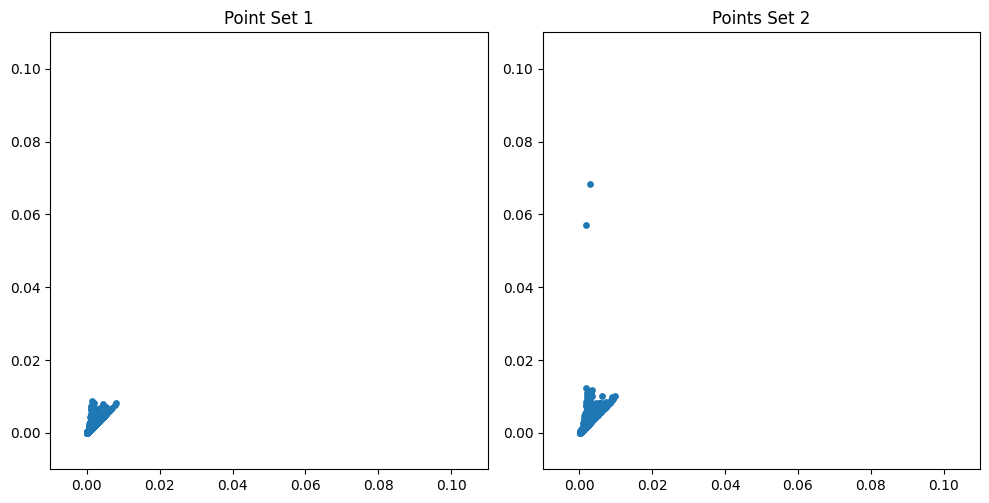

In [44]:
#The persistence diagrams of these two types of samplings are quite different, as the torus has two significant features in degree 1

sample_sphere_pd=compute_PD(Sample_points_sphere)
sample_torus_pd=compute_PD(Sample_points_torus)



plot_two_point_sets(sample_sphere_pd, sample_torus_pd, point_size=15, ax_limit=0.1)






In [45]:
#Sample 1000 of each

iterations=1000
num_points=1000

Points_Sphere=[]
Points_Torus=[]
PDs_Sphere=[]
PDs_Torus=[]

for i in range(iterations):
  Points_Sphere.append(sample_sphere(1000, 0.5))
  Points_Torus.append(sample_torus(1000, 0.5,0.23874))
  PDs_Sphere.append(compute_PD(Points_Sphere[i]))
  PDs_Torus.append(compute_PD(Points_Torus[i]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [46]:
#Again we normalize by total persistence and by "relevant max death value"
PDs_Sphere_raw=normalize_by_tot_pers(PDs_Sphere)
PDs_Torus_raw=normalize_by_tot_pers(PDs_Torus)

norm_val=max(get_overall_norm_val(PDs_Sphere_raw), get_overall_norm_val(PDs_Torus_raw))
print(norm_val)

PDs_Torus=[(1/norm_val)*x for x in PDs_Torus_raw]
PDs_Sphere=[(1/norm_val)*x for x in PDs_Sphere_raw]

0.11230574637567856


0.03634978737693494
0.11230574637567856


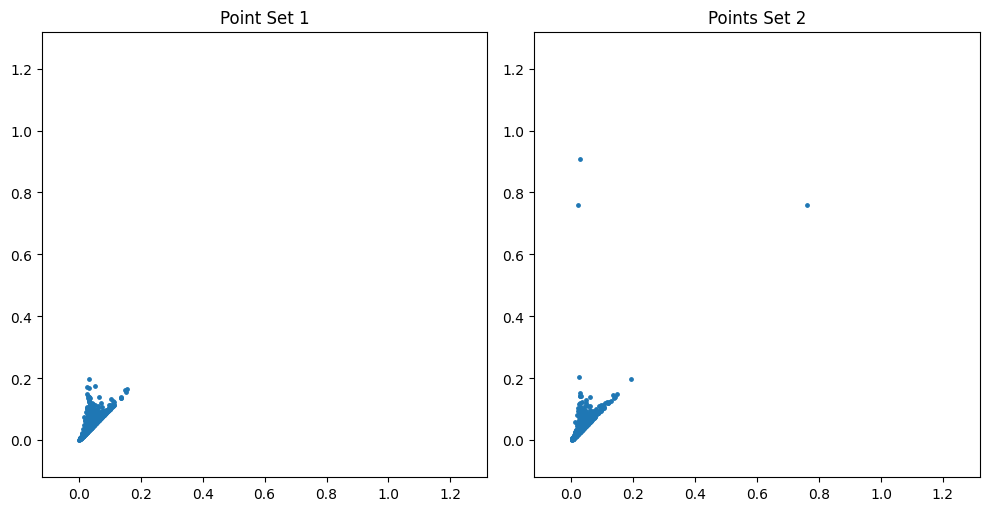

In [47]:
#Finding the diagram that defined the norm_val
vals_S=[get_norm_val(PDs_Sphere_raw[i]) for i in range(iterations)]
vals_T=[get_norm_val(PDs_Torus_raw[i]) for i in range(iterations)]


print(np.max(vals_S))
print(np.max(vals_T))

if norm_val in vals_S:
  index = vals_S.index(norm_val)
if norm_val in vals_T:
  index = vals_T.index(norm_val)


sample_pd_Sphere=PDs_Sphere[index]
sample_pd_Torus=PDs_Torus[index]

plot_two_point_sets(sample_pd_Sphere, sample_pd_Torus, ax_limit=1.2)

In [50]:
#Plotting the nailbed visualization for these specific persistence diagrams
MPHvect_nailbed(sample_pd_Sphere, number_of_triangulations=5, y_max=1)
MPHvect_nailbed(sample_pd_Torus, number_of_triangulations=5, y_max=1)

Output hidden; open in https://colab.research.google.com to view.

In [51]:
#Now let us map each of the 2000 persistence diagrams to a vector
n_list, p_list=collect_vertices(1,7,4)

Vectors_Sphere=[]
Vectors_Torus=[]
for i in range(iterations):
  Vectors_Sphere.append(vectorize_fast(n_list, p_list, np.array(PDs_Sphere[i]), [1 for _ in range(len(PDs_Sphere[i]))]))
  Vectors_Torus.append(vectorize_fast(n_list, p_list, np.array(PDs_Torus[i]), [1 for _ in range(len(PDs_Torus[i]))]))

  sys.stdout.write(f"\r{i+1}/{iterations}")
  sys.stdout.flush()
print()

1000/1000


In [52]:
#compute the average vector of each class
Sphere_mean=np.mean(Vectors_Sphere,axis=0)
Torus_mean=np.mean(Vectors_Torus,axis=0)

print("Mean of Sphere Vectors", Sphere_mean)
print("Mean of Torus Vectors", Torus_mean)

Mean of Sphere Vectors [69.60579234  8.9122635   1.18838917 ...  0.          0.
  0.        ]
Mean of Torus Vectors [76.3323693   6.52969208  0.24096139 ...  0.          0.
  0.        ]


In [53]:
#Here we plot the vectorization of the average vectors from each sampling, and the difference between the two

vis_vector(Sphere_mean, n_list, p_list, norm_val=norm_val, title='Average Vector: Sphere')
vis_vector(Torus_mean, n_list, p_list, norm_val=norm_val, title='Average Vector: Torus')
vis_vector(Torus_mean-Sphere_mean, n_list, p_list, norm_val=norm_val, title='Difference of Average Vectors')

Observed accuracy: 1.0000
Permutation p-value: 0.0000


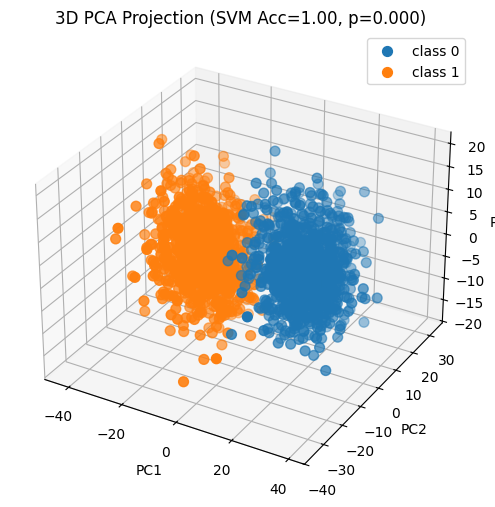

Standard Deviation of Sphere Vectors 1.8517338320469812
Standard Deviation of Torus Vectors 1.8818399003078337


In [54]:
#We now attempt to classify these vectors using Support Vector Machine (SVM).
#We also do a permutation test with 1000 permutations and calculate a p-value. Finally, we plot the PCA projection onto 3 components.

do_SVM_and_PCA(Vectors_Sphere, Vectors_Torus)
print("Standard Deviation of Sphere Vectors", np.std(Vectors_Sphere))
print("Standard Deviation of Torus Vectors", np.std(Vectors_Torus))